# Plot the decomposition of the Logic gates:

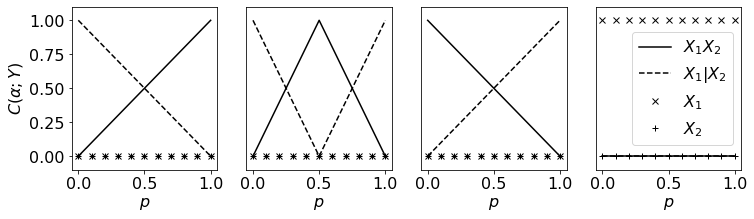

In [ ]:
import matplotlib.pyplot as plt

fig, ax  = plt.subplots(1, 4, figsize=(12, 3))
ps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# OR
ax[0].plot(ps, [p for p in ps], label=r'$X_1X_2$', linestyle='-', color='k')
ax[0].plot(ps, [(1-p) for p in ps], label=r'$X_1|X_2$', linestyle='--', color='k')
ax[0].plot(ps, [0 for x in ps], label=r'$X_1$', marker='x', linestyle='', color='k')
ax[0].plot(ps, [0 for x in ps], label=r'$X_2$', marker='+', linestyle='', color='k')

# XOR
ax[1].plot(ps, [(1-abs(1-2*p)) for p in ps], label=r'$X_1X_2$', linestyle='-', color='k')
ax[1].plot(ps, [abs(1-2*p) for p in ps], label=r'$X_1|X_2$', linestyle='--', color='k')
ax[1].plot(ps, [0 for x in ps], label=r'$X_1$', marker='x', linestyle='', color='k')
ax[1].plot(ps, [0 for x in ps], label=r'$X_2$', marker='+', linestyle='', color='k')

# AND
ax[2].plot(ps, [(1-p) for p in ps], label=r'$X_1X_2$', linestyle='-', color='k')
ax[2].plot(ps, [p for p in ps], label=r'$X_1|X_2$', linestyle='--', color='k')
ax[2].plot(ps, [0 for x in ps], label=r'$X_1$', marker='x', linestyle='', color='k')
ax[2].plot(ps, [0 for x in ps], label=r'$X_2$', marker='+', linestyle='', color='k')

# COPY
ax[3].plot(ps, [0 for p in ps], label=r'$X_1X_2$', linestyle='-', color='k')
ax[3].plot(ps, [0 for p in ps], label=r'$X_1|X_2$', linestyle='--', color='k')
ax[3].plot(ps, [1 for x in ps], label=r'$X_1$', marker='x', linestyle='', color='k')
ax[3].plot(ps, [0 for x in ps], label=r'$X_2$', marker='+', linestyle='', color='k')

for a in ax.flatten():
    a.set_ylim(-0.1, 1.1)

for a in ax:
    a.set_xlabel(r'$p$')

ax[0].set_ylabel(r'$C(\alpha;Y)$')

for a in ax[1:]:
    a.set_yticks([])

# increase font size
for a in ax.flatten():
    a.title.set_size(20)
    a.xaxis.label.set_size(16)
    a.yaxis.label.set_size(16)
    a.tick_params(axis='both', which='major', labelsize=16)
    a.legend(fontsize=16)

# remove legend 
for a in ax.flatten()[:-1]:
    a.get_legend().remove()

plt.show()

# Analysis of the cellular automata

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from collections import Counter
import scipy.sparse as sp

# ## 1. Load Möbius function and antichains.
mobius_N3 = sp.load_npz('mobius_matrix/antiChainLattice_mobiusFns_N=3.npz')
antichains_N3 = pd.read_csv('mobius_matrix/antiChains_N=3.csv', index_col=0).values[:, 0]
antichains_N3 = [alpha.replace(' ', '').replace('0', 'A').replace('1', 'B').replace('2', 'C') for alpha in antichains_N3]
antichains_N3 = [[a.replace('[', '').replace(']', '').split(',') for a in alpha.split('],[')] for alpha in antichains_N3]

# ## 2. Helper Functions (CA & PCD)

def get_rule_mapping(rule_number):
    """Rule num (0-255) to dict mapping {'110': 0, ...}."""
    binary = format(rule_number, '08b')
    patterns = ['111', '110', '101', '100', '011', '010', '001', '000']
    return {p: int(b) for p, b in zip(patterns, binary)}

def get_next_state(neighborhood, rule_mapping):
    """Get next state for a cell given its 3-neighbor state list/array."""
    pattern = ''.join(str(x) for x in neighborhood)
    return rule_mapping[pattern]

def evolve_ca(rule_mapping, initial_state, steps):
    """Evolve 1D CA (periodic boundaries) for n steps."""
    n = len(initial_state)
    if n == 0: return np.empty((steps + 1, 0), dtype=int)
    states = np.zeros((steps + 1, n), dtype=int)
    states[0] = initial_state
    for t in range(steps):
        current_state = states[t]
        next_state_row = np.zeros(n, dtype=int)
        for i in range(n):
            neighborhood = [current_state[(i - 1) % n], current_state[i], current_state[(i + 1) % n]]
            next_state_row[i] = get_next_state(neighborhood, rule_mapping)
        states[t+1] = next_state_row
    return states

def estimate_joint_probabilities(ca_states, burn_in_ratio=0.05, vars_to_estimate=['A', 'B', 'C']):
    """Estimate P(A_t, C_t) or P(B_t, C_t) from CA states (post burn-in)."""

    num_steps, n = ca_states.shape
    start_step = int(num_steps * burn_in_ratio)
    triplets = [(ca_states[t, i], ca_states[t, (i + 1) % n], ca_states[t, (i + 2) % n])
                for t in range(start_step, num_steps) for i in range(n)]
    counts = Counter(triplets)
    total = len(triplets)
    probs = {p: c / total for p, c in counts.items()}
    for p in product([0, 1], repeat=3): probs.setdefault(p, 0.0)
    return probs

def compute_marginal(joint_prob, variables):
    """Compute marginal probability from joint distribution over variables A, B, C."""
    # Map variable names to indices
    var_map = {'A': 0, 'B': 1, 'C': 2}
    indices = [var_map[var] for var in variables]
    
    marginal = {}
    for state, prob in joint_prob.items():
        # Extract values for requested variables
        marginal_state = tuple(state[i] for i in indices)
        
        # Add probability
        if marginal_state in marginal:
            marginal[marginal_state] += prob
        else:
            marginal[marginal_state] = prob
            
    return marginal


def calculate_expected_outcome_do(rule, empirical_probs, do_dict = {}):
    """Calculate expected outcome of a rule given do intervention on variables. This implements the back-door correction by 'controlling' for the non-intervened variables."""
    rule_mapping = get_rule_mapping(rule)
    outcomes = []
    weights = []

    nonIntervened = [v for v in ['A', 'B', 'C'] if v not in do_dict.keys()]
    neighborhood = {}
    # Set the values of the intervened variables
    for k, v in do_dict.items():
        neighborhood[k] = v

    for nonIntVals in product([0,1], repeat=len(nonIntervened)):
        # Set the values of the non-intervened variables
        for k, c in zip(nonIntervened, nonIntVals):
            neighborhood[k] = c
        neighborhood_state = tuple(v for _, v in sorted(neighborhood.items()))
        # marginalize over the non-intervened variable:
        prob = compute_marginal(empirical_probs, nonIntervened)[nonIntVals]

        y = get_next_state(neighborhood_state, rule_mapping)
        outcomes.append(y)
        weights.append(prob)
   
    return np.average(outcomes, weights=weights)

def calculate_MACE(rule_number, variables_S, prior_probs_BC):
    """Calculate Maximal Average Causal Effect for set S."""
    if not variables_S: return 0.0
    states = list(product([0, 1], repeat=len(variables_S)))
    expected_outcomes = {state: calculate_expected_outcome_do(rule_number, prior_probs_BC, dict(zip(variables_S, state))) for state in states}
    return max(abs(expected_outcomes[s1] - expected_outcomes[s2]) for s1 in states for s2 in states)

def calculate_MACE_redundant(rule_number, antichain_alpha, prior_probs_BC):
    """Calculate MACE_cap(alpha; Y) = min_{A in alpha} MACE(X_A; Y)."""
    if not antichain_alpha: raise ValueError("Antichain empty.")
    return min(calculate_MACE(rule_number, sorted(elem_A), prior_probs_BC) for elem_A in antichain_alpha)

def perform_causal_decomposition(rule, prior, antichains, mobius_matrix):
    """Performs PCD: C(beta) = sum_{alpha<=beta} mu(alpha, beta) * MACE_cap(alpha)."""
    mace_cap_vec = np.array([calculate_MACE_redundant(rule, alpha, prior) for alpha in antichains])
    # C = M^T * V (where V = mace_cap_vec)
    partial_contributions = np.dot(mobius_matrix.toarray().T, mace_cap_vec)
    keys = ['C_' + '_'.join([''.join(sorted(a)) for a in sorted(alpha, key=lambda x: (len(x), ''.join(sorted(x))))]) for alpha in antichains]
    return dict(zip(keys, partial_contributions))


In [135]:

# ## 3. Simulation and Analysis Execution

# --- Parameters ---
rules_to_analyze = [30, 54, 86, 90, 110, 190, 240, 250]
simulation_steps = 10000
ca_size = 100
burn_in_fraction = 0.05
num_random_runs = 20


# --- Main Loop ---
all_results = {}
priors = { # Define prior P(B,C) distributions
    'Zeros': {state: 0 for state in product([0, 1], repeat=3)},
    'Uniform': {state: 0.125 for state in product([0, 1], repeat=3)}
}
priors['Zeros'][(0, 0, 0)] = 1.0

for rule in rules_to_analyze:
    print(f"Analyzing Rule {rule}...")
    rule_results = {}
    current_rule_mapping = get_rule_mapping(rule)

    # Zeros & Uniform Priors
    rule_results['Zeros'] = perform_causal_decomposition(rule, priors['Zeros'], antichains_N3, mobius_N3)
    rule_results['Uniform'] = perform_causal_decomposition(rule, priors['Uniform'], antichains_N3, mobius_N3)

    # Middle-1 Init (Empirical Prior)
    initial_state_mid = np.zeros(ca_size, dtype=int)
    if ca_size > 0: initial_state_mid[ca_size // 2] = 1
    states_mid = evolve_ca(current_rule_mapping, initial_state_mid, simulation_steps)
    prior_mid = estimate_joint_probabilities(states_mid, burn_in_fraction)
    rule_results['Middle-1'] = perform_causal_decomposition(rule, prior_mid, antichains_N3, mobius_N3)

    # Random Init (Empirical Prior - Mean/Std)
    random_runs_list = []
    for _ in range(num_random_runs):
        states_rand = evolve_ca(current_rule_mapping, np.random.randint(0, 2, ca_size), simulation_steps)
        prior_rand = estimate_joint_probabilities(states_rand, burn_in_fraction)
        random_runs_list.append(perform_causal_decomposition(rule, prior_rand, antichains_N3, mobius_N3))

    if random_runs_list:
        ref_keys = random_runs_list[0].keys()
        rule_results['Random_Mean'] = {k: np.mean([r.get(k, 0.) for r in random_runs_list]) for k in ref_keys}
        rule_results['Random_Std'] = {k: np.std([r.get(k, 0.) for r in random_runs_list]) for k in ref_keys}
    else:
        rule_results['Random_Mean'] = {k: 0. for k in rule_results['Uniform']}
        rule_results['Random_Std'] = {k: 0. for k in rule_results['Uniform']}

    all_results[rule] = rule_results
print("Analysis complete.")

Analyzing Rule 30...
Analyzing Rule 54...
Analyzing Rule 86...
Analyzing Rule 90...
Analyzing Rule 110...
Analyzing Rule 190...
Analyzing Rule 240...
Analyzing Rule 250...
Analysis complete.


Generating plot...


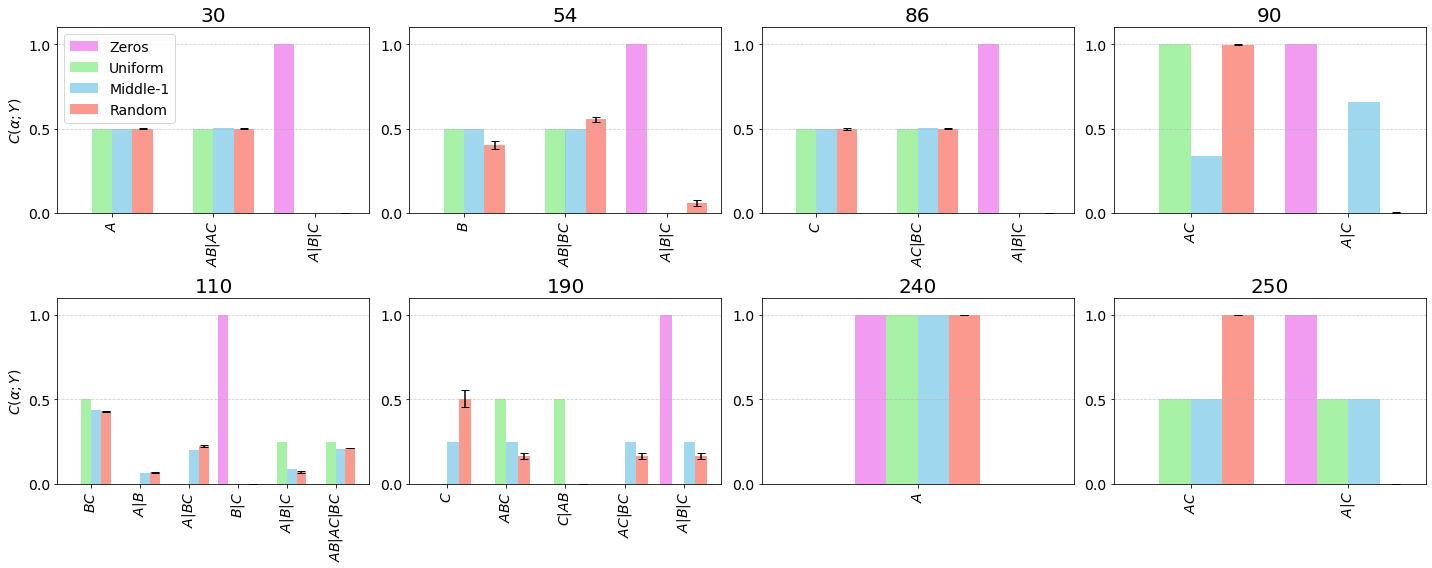

In [134]:

# ## 4. Plotting

print("Generating plot...")
plot_labels_N3 = [r'${' + r'|'.join([''.join(sorted(a)) for a in sorted(alpha, key=lambda x: (len(x), ''.join(sorted(x))))]) + '}$' for alpha in antichains_N3]
num_rules = len(rules_to_analyze)
ncols = min(4, num_rules); nrows = (num_rules + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
bar_width = 0.2
plot_threshold = 0.01
measure_keys = list(all_results[rules_to_analyze[0]]['Uniform'].keys())
labels_dict = dict(zip(measure_keys, plot_labels_N3))
axes_flat = axes.flatten()

for i, rule in enumerate(rules_to_analyze):
    ax = axes_flat[i]; data = all_results[rule]
    vals = {p: np.array([data[p].get(m, 0.) for m in measure_keys])
            for p in ['Zeros', 'Uniform', 'Middle-1', 'Random_Mean']}
    stds = np.array([data['Random_Std'].get(m, 0.) for m in measure_keys])

    mask = (vals['Zeros'] > plot_threshold) | (vals['Uniform'] > plot_threshold) | \
            (vals['Middle-1'] > plot_threshold) | (vals['Random_Mean'] > plot_threshold)

    f_keys = np.array(measure_keys)[mask]; f_labels = [labels_dict[k] for k in f_keys]
    f_vals = {p: vals[p][mask] for p in vals}; f_stds = stds[mask]
    x_idx = np.arange(len(f_labels))

    ax.bar(x_idx - bar_width*1.5, f_vals['Zeros'], bar_width, label='Zeros', color='violet', alpha=0.8)
    ax.bar(x_idx - bar_width*0.5, f_vals['Uniform'], bar_width, label='Uniform', color='lightgreen', alpha=0.8)
    ax.bar(x_idx + bar_width*0.5, f_vals['Middle-1'], bar_width, label='Middle-1', color='skyblue', alpha=0.8)
    ax.bar(x_idx + bar_width*1.5, f_vals['Random_Mean'], bar_width, yerr=f_stds, label='Random', color='salmon', capsize=4, alpha=0.8)

    ax.set_title(f"{rule}", fontsize=20); ax.set_xticks(x_idx)
    ax.set_xticklabels(f_labels, rotation=90, fontsize=14); ax.set_yticks(np.arange(0, 1.1, 0.5))
    ax.tick_params(axis='y', labelsize=14); ax.set_ylim(0, 1.1); ax.grid(axis='y', linestyle='--', alpha=0.6)
    if len(f_labels)==1: ax.set_xlim(-1, 1)
    if i == 0: ax.legend(fontsize=14)
    if i % ncols == 0: ax.set_ylabel('$C(\\alpha; Y)$', fontsize=14)

for j in range(i + 1, nrows * ncols): fig.delaxes(axes_flat[j]) # Hide unused
plt.tight_layout()
plt.show()